In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import construction_helpers as ch # Needed for @ auto-alignment
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import websocket_transfer.capture as cap

Requesting render from server...
Received from server: {"msgType": "Connected"}


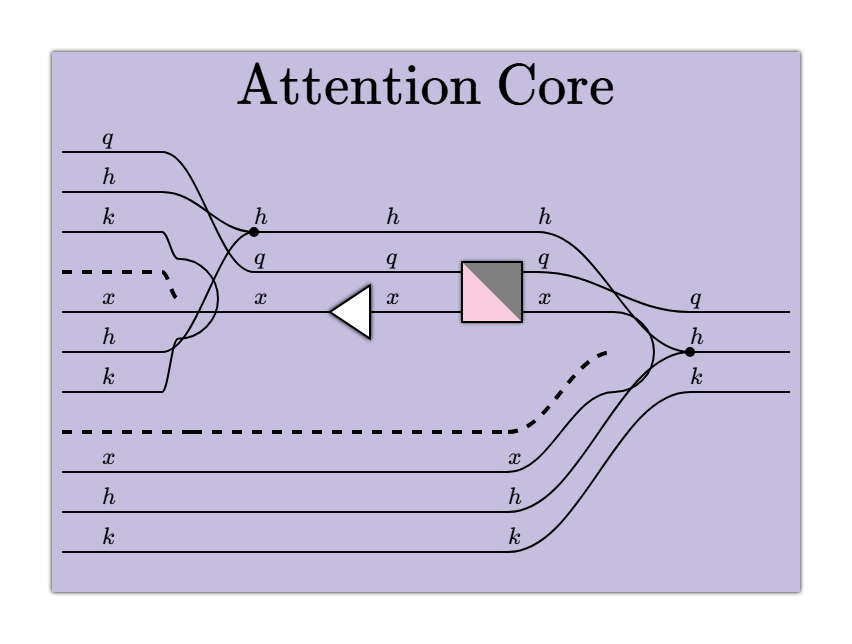

In [3]:
''' Attention Layer '''
qk_matmul = ops.Einops.template('q h k, x h k -> h q x')
softmax = ops.SoftMax.template()
mask = ops.WeightedTriangularLower().template()
sv_matmul = ops.Einops.template('h q x, x h k -> q h k')
attention_core = cat.Block.template(
    qk_matmul @ softmax @ mask @ sv_matmul,
    title='Attention Core',
    fill_color='#C5BEDF'
)
await cap.capture_morphism(attention_core)

Requesting render from server...
Received from server: {"msgType": "Connected"}


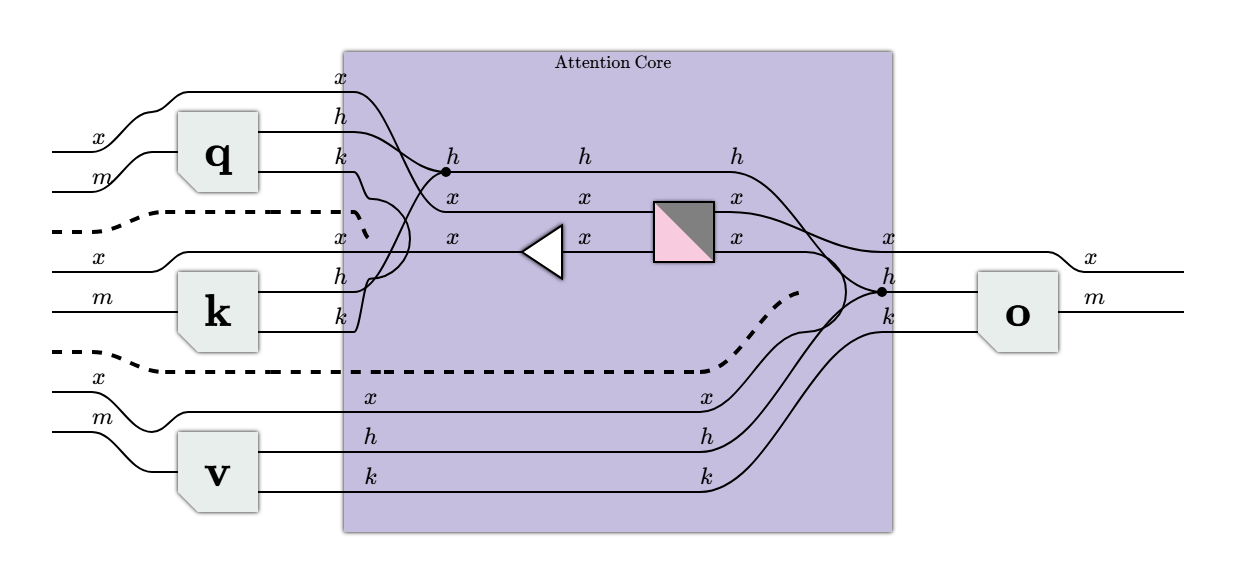

In [4]:
Lq = ops.Linear.template(('m',), 2, 'q')
Lk = ops.Linear.template(('m',), 2, 'k')
Lv = ops.Linear.template(('m',), 2, 'v')
Lo = ops.Linear.template(2, ('m',), 'o')
attention_layer = (Lq * Lk * Lv) @ attention_core @ Lo

await cap.capture_morphism(attention_layer)

Requesting render from server...
Received from server: {"msgType": "Connected"}


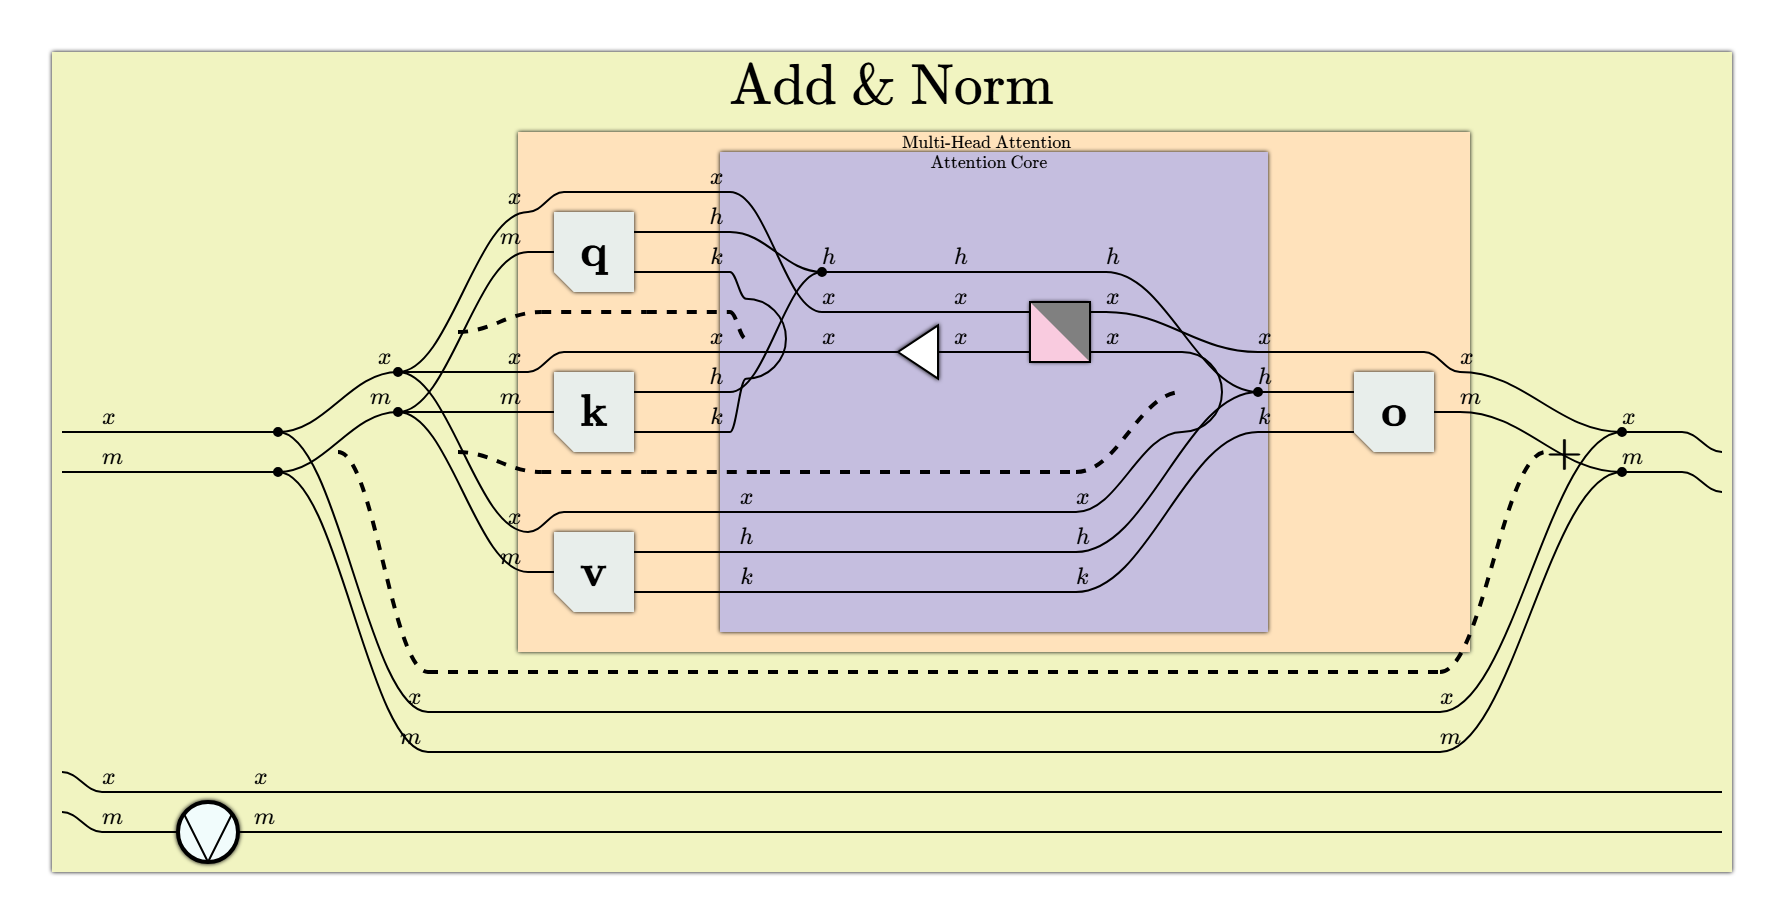

In [5]:
addition = ops.AdditionOp.template()

def res[B: cat.Datatype, A: cat.Axis](target: cat.BroadcastedCategory[B, A]) -> cat.Block[
    cat.Array[B, A], cat.BroadcastedCategory[B, A]
]:
    return cat.Block.template(
        (0,0) 
        @ target 
        @ ops.AdditionOp.template() 
        @ ops.Normalize.template(),
        title='Add \\& Norm',
        fill_color='#F1F4C1'
    )

res_attention = res(
    (0,0,0) 
    @ cat.Block.template(
        attention_layer,
        title='Multi-Head Attention',
        fill_color='#FFE2BB'
    )
)
await cap.capture_morphism(res_attention)

In [6]:
ffn = cat.Block.template(
    ops.Linear.template(1, ('d_ff',), 'in') 
    @ ops.Elementwise.template() 
    @ ops.Linear.template(('d_ff',), 1, 'out'),
    title='Feed Forward',
    fill_color='#C1E8F7'
)
res_ffn = res(ffn)

transformer_layer = res_attention @ res_ffn

attention_ffn_network = cat.Block.template(
    transformer_layer,
    repetition=6,
    title='Transformer Layer',
    fill_color='#F3F3F4'
)

In [7]:
vocab_size = fd.DynamicName('v', settings=fd.DynamicNameSettings(overline=True))

embedding = cat.Block.template(
    ops.Embedding.template(vocab_size,),
    title='Embedding',
    fill_color='#FCE0E1')
aggregator = cat.Block.template(
    ops.Linear.template(1, (vocab_size,)) @ ops.SoftMax.template(),
    title='Aggregator',
    fill_color='#DBDFEF'
)   
transformer = embedding @ attention_ffn_network @ aggregator

In [8]:
from data_transfer import json as jst

json_transformer = jst.TermJSONConverter.export(transformer, 'outputs/transformer.json')

Requesting render from server...
Received from server: {"msgType": "Connected"}


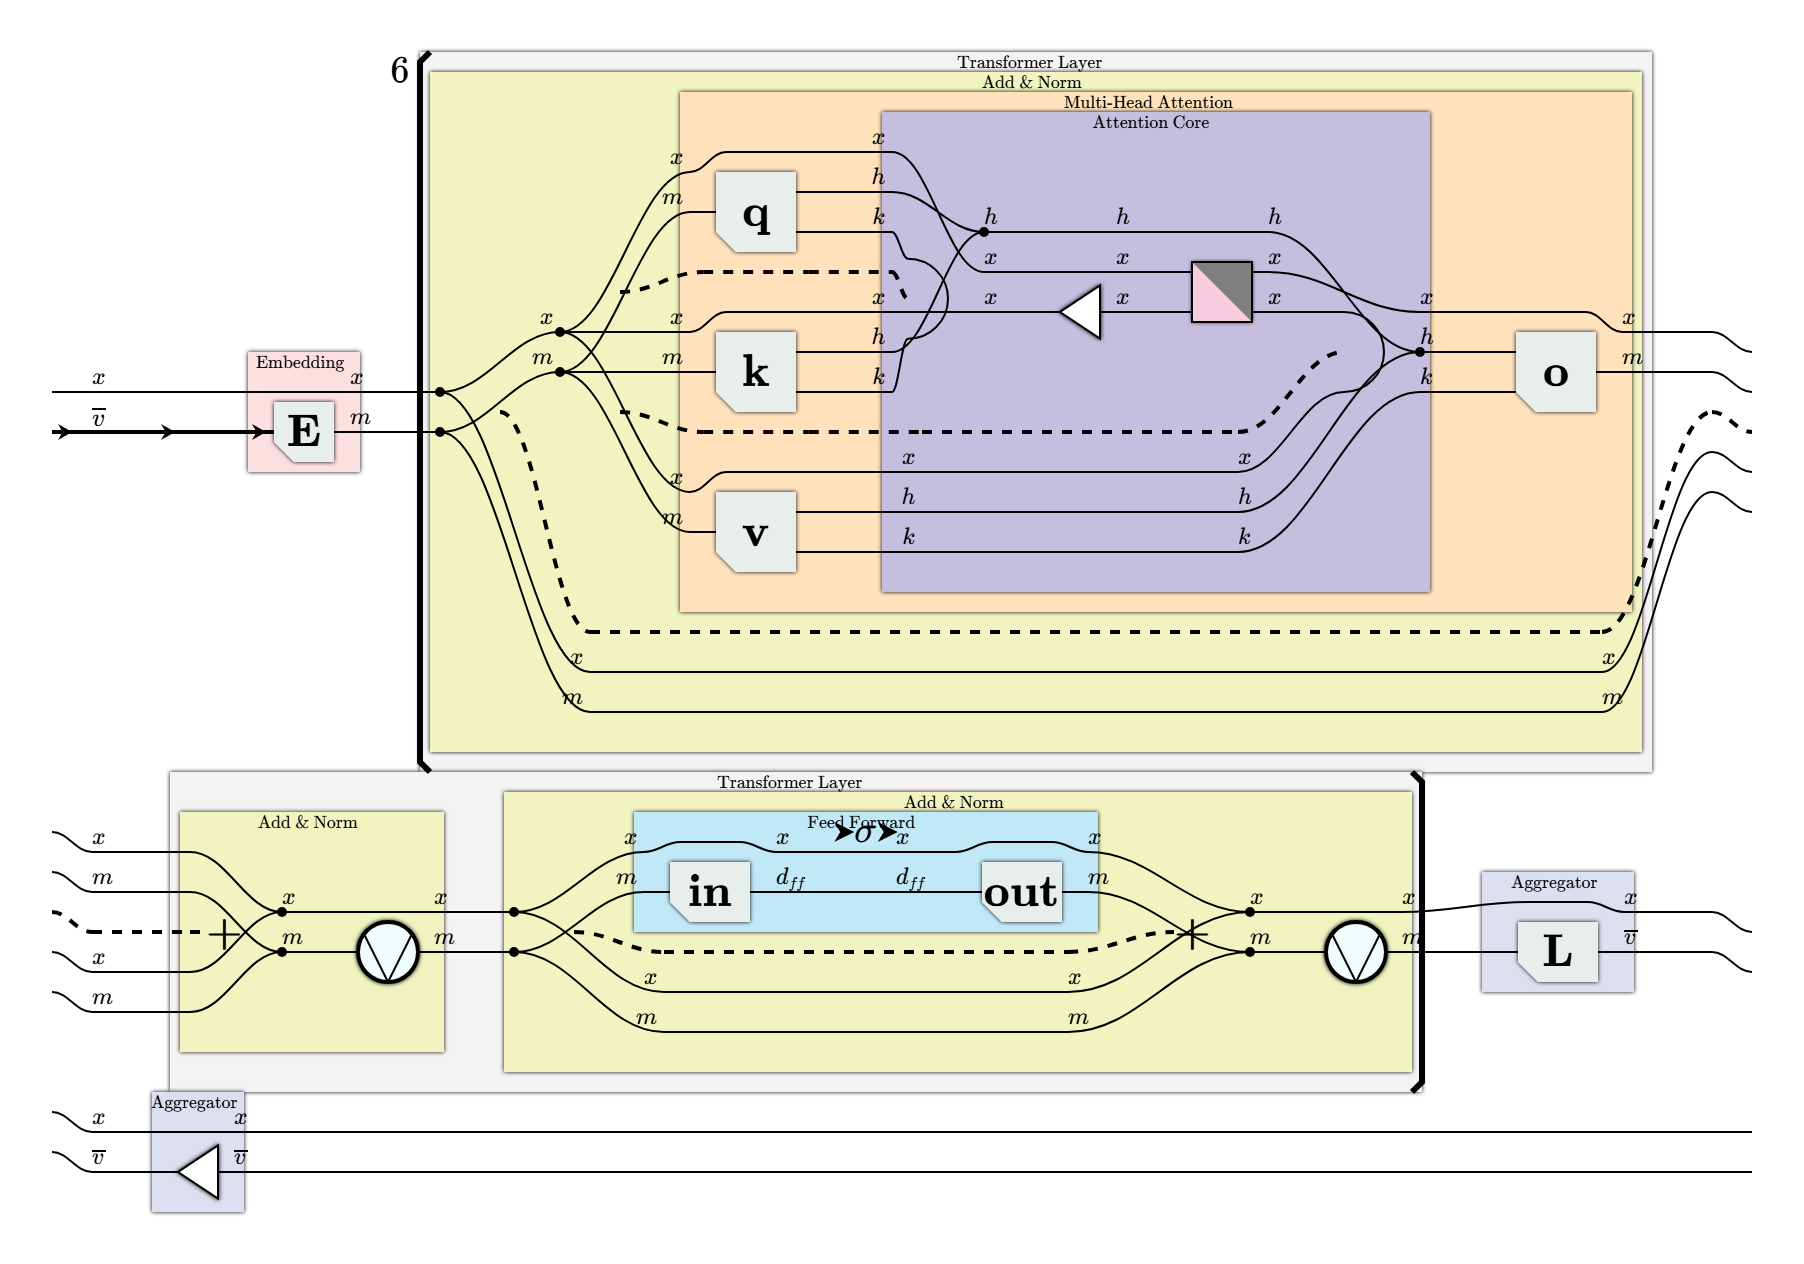

In [9]:
await cap.capture_morphism(transformer)

Requesting render from server...
Received from server: {"msgType": "Connected"}


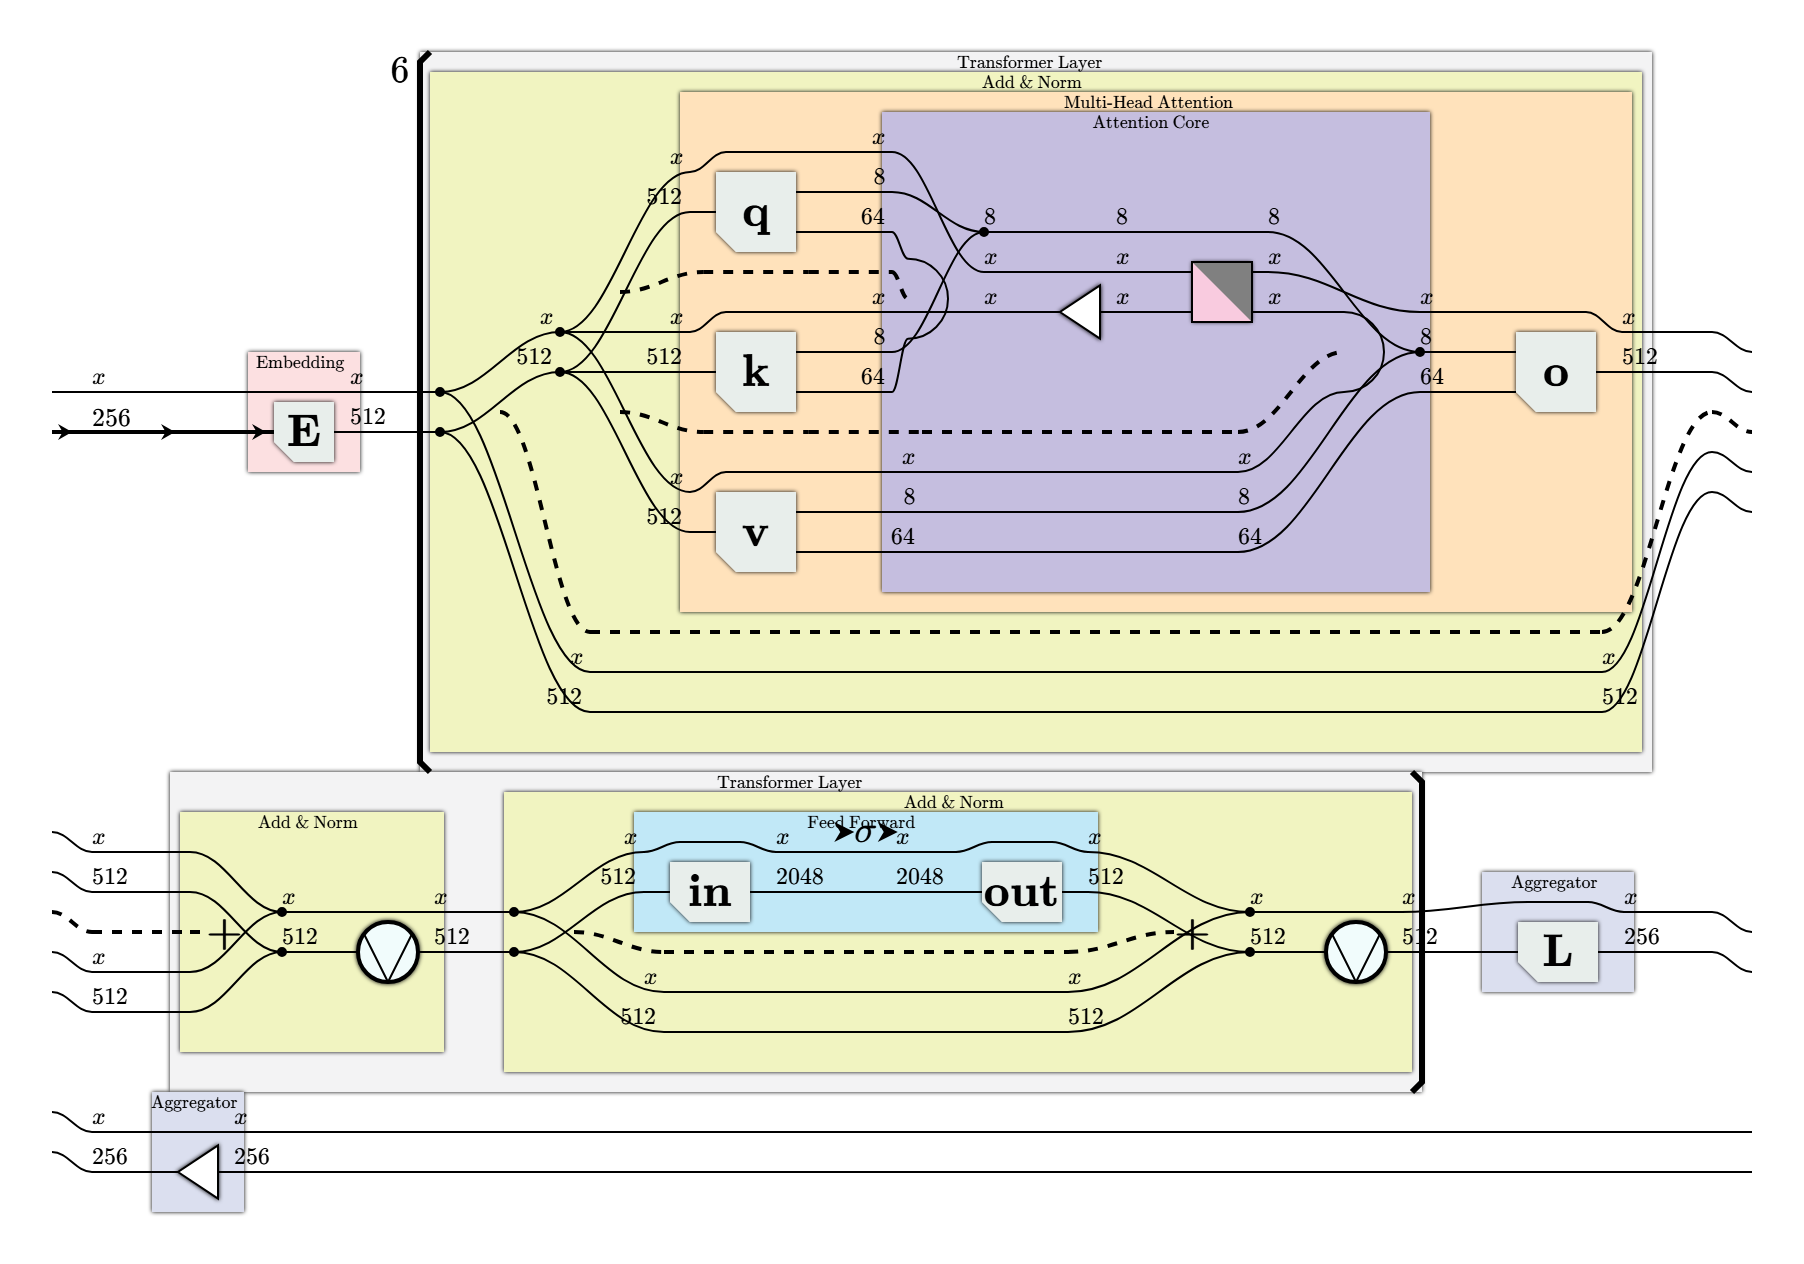

In [10]:
## Assign Axis sizes

import term_utilities.generate_config as gc
config = gc.NumericConfig()
config.incorporate(transformer)
config.assign_value('v', 256)
config.assign_value('m', 512)
config.assign_value('d', 2048)
config.assign_value('k', 64)
config.assign_value('h', 8)
transformer512 = config.apply_context(transformer)
await cap.capture_morphism(transformer512)

In [11]:
try:
    import torch
    import einops
    torch_installed = True
except ModuleNotFoundError:
    torch_installed = False

In [12]:
if torch_installed:
    import torch_compile.torch_compile as tc
    module = tc.ConstructedModule.construct(transformer512)

In [13]:
if torch_installed:
    import torch
    # Token ids must fall inside the vocabulary, set to 256 above.
    dummy = torch.randint(0, 256, (3, 2,))
    result = module(dummy)
    print([x.shape for x in result])

[torch.Size([3, 2, 256])]
